In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load dataset
dataset = pd.read_csv(r"C:\Users\Dell\Downloads\logit classification.csv")

In [4]:
# Features and target
X = dataset.iloc[:,[2,3]].values   # Age, Salary
y = dataset.iloc[:,4].values       # Purchased

In [5]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=0
)

In [7]:
# Hyperparameter Tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5,6,7],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

In [8]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [9]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [10]:
# Best model
model = grid.best_estimator_

In [11]:
# Prediction

y_pred = model.predict(X_test)

In [12]:
# Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix


print("Accuracy:", accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

Accuracy: 0.95
Confusion Matrix:
 [[55  3]
 [ 1 21]]


ROC AUC: 0.9494514106583072


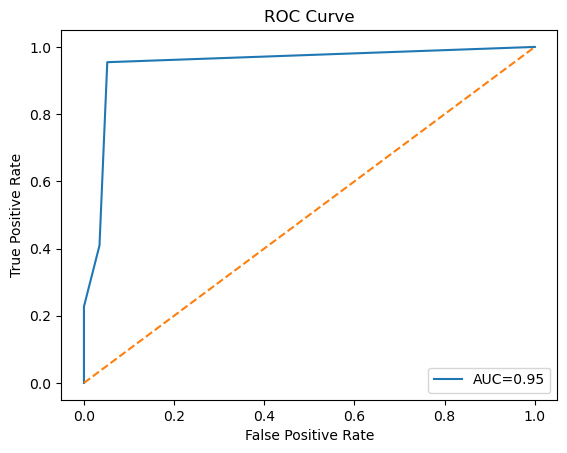

In [13]:
# ROC Curve
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test,y_prob)
print("ROC AUC:",roc)

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr,label="AUC="+str(round(roc,2)))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
